In [1]:
# 6-23-2026

In [12]:
import pandas as pd
import numpy as np
from scipy.stats import kendalltau, spearmanr
import matplotlib.pyplot as plt

In [34]:
xgb_t_5 = pd.read_csv("transfer_matrix_spearman_xgb_5.csv")
xgb_t_10 = pd.read_csv("transfer_matrix_spearman_xgb_10.csv")


nn_t_5 = pd.read_csv("transfer_matrix_spearman_nn_5.csv")
nn_t_10 = pd.read_csv("transfer_matrix_spearman_nn_10.csv")

rf_t_10 = pd.read_csv("transfer_matrix_spearman_rf_10.csv")
rf_t_5 = pd.read_csv("transfer_matrix_spearman_rf_5.csv")

In [35]:
xgb_t_10.set_index("Unnamed: 0", inplace=True)
xgb_t_10.index.name = None
xgb_t_5.set_index("Unnamed: 0", inplace=True)
xgb_t_5.index.name = None

nn_t_10.set_index("Unnamed: 0", inplace=True)
nn_t_10.index.name = None
nn_t_5.set_index("Unnamed: 0", inplace=True)
nn_t_5.index.name = None

rf_t_10.set_index("Unnamed: 0", inplace=True)
rf_t_10.index.name = None
rf_t_5.set_index("Unnamed: 0", inplace=True)
rf_t_5.index.name = None

In [15]:
tau_xgb, _ = kendalltau(xgb_t_10.values.flatten(), xgb_t_5.values.flatten())
tau_xgb

np.float64(0.7814466963255892)

In [28]:
tau_nn, _ = kendalltau(nn_t_10.values.flatten(), nn_t_5.values.flatten())
tau_nn

np.float64(0.5302506029149627)

In [36]:
tau_rf, _ = kendalltau(rf_t_10.values.flatten(), rf_t_5.values.flatten())
tau_rf

np.float64(0.9261253164367351)

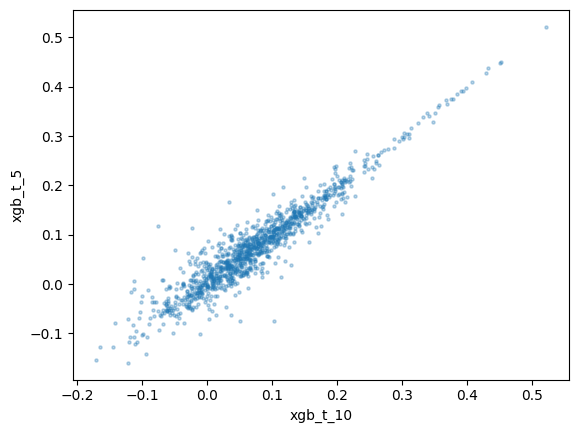

In [17]:
plt.scatter(xgb_t_10.values.flatten(), xgb_t_5.values.flatten(), alpha=0.3, s=5)
plt.xlabel("xgb_t_10")
plt.ylabel("xgb_t_5")
plt.show()

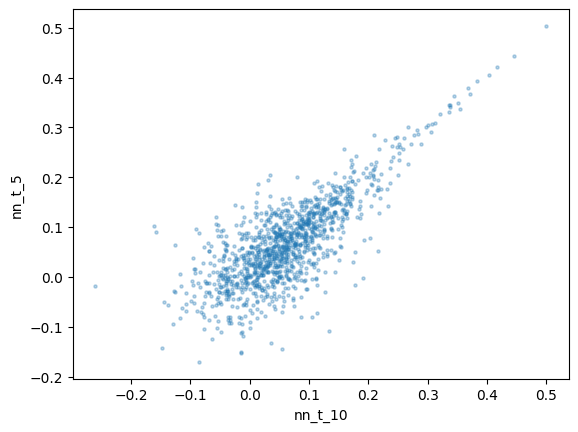

In [29]:
plt.scatter(nn_t_10.values.flatten(), nn_t_5.values.flatten(), alpha=0.3, s=5)
plt.xlabel("nn_t_10")
plt.ylabel("nn_t_5")
plt.show()

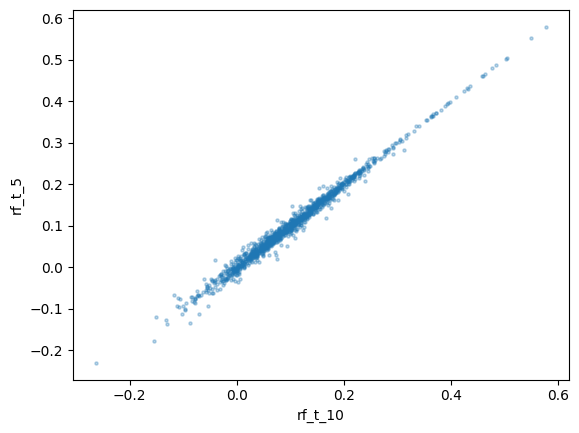

In [37]:
plt.scatter(rf_t_10.values.flatten(), rf_t_5.values.flatten(), alpha=0.3, s=5)
plt.xlabel("rf_t_10")
plt.ylabel("rf_t_5")
plt.show()

In [38]:
def off_diagonal(df):
    # pull everything except the diagonal, return as flat array
    arr = df.values.copy().astype(float)
    np.fill_diagonal(arr, np.nan)
    return arr.flatten()

xgb_10_off = off_diagonal(xgb_t_10)
xgb_5_off = off_diagonal(xgb_t_5)

nn_10_off = off_diagonal(nn_t_10)
nn_5_off = off_diagonal(nn_t_5)

rf_10_off = off_diagonal(rf_t_10)
rf_5_off = off_diagonal(rf_t_5)

In [19]:
mask = ~np.isnan(xgb_10_off) & ~np.isnan(xgb_5_off)

In [ ]:
diag_xgb_10 = np.diag(xgb_t_10.values)
diag_xgb_5 = np.diag(xgb_t_5.values)
xgb_diag_corr, _ = spearmanr(diag_xgb_10, diag_xgb_5)
xgb_diag_corr

np.float64(0.9960275019098548)

In [32]:
diag_nn_10 = np.diag(nn_t_10.values)
diag_nn_5 = np.diag(nn_t_5.values)
nn_diag_corr, _ = spearmanr(diag_nn_10, diag_nn_5)
nn_diag_corr

np.float64(0.974331550802139)

In [39]:
diag_rf_10 = np.diag(rf_t_10.values)
diag_rf_5 = np.diag(rf_t_5.values)
rf_diag_corr, _ = spearmanr(diag_rf_10, diag_rf_5)
rf_diag_corr

np.float64(0.9978609625668448)

In [40]:
for name_a, name_b, a, b in [("xgb_10", "xgb_5", xgb_10_off, xgb_5_off), ("nn_10", "nn_5", nn_10_off, nn_5_off), ("rf_10", "rf_5", rf_10_off, rf_5_off)]:
    tau, _ = kendalltau(a[mask], b[mask])
    print(f"{name_a} vs {name_b}, off-diagonal only: kendall tau={tau:.3f}")

xgb_10 vs xgb_5, off-diagonal only: kendall tau=0.768
nn_10 vs nn_5, off-diagonal only: kendall tau=0.502
rf_10 vs rf_5, off-diagonal only: kendall tau=0.922


In [43]:
t_final = (rf_t_10 + rf_t_5) / 2

In [44]:
t_final.to_csv("rf_transfer_matrix.csv")